## Overview of Diabetes Readmission Prediction
Using a dataset representing ten years (1999-2008) of clinical care at 130 US hospitals to determine the leading variables of readmission so that hospitals can start taking corrective action and reduce the 30-day readmission rate.

Python Version: 3.13.10

## Installing and Importing Required Libraries
Along with installing the libraries, install ipykernels

In [130]:
# installing libraries
!pip install seaborn
!pip install missingno
!pip install xgboost
!pip install catboost
!pip install regex
!pip install sklearn
!pip install pandas
!pip install numpy
!pip install imblearn
!pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error

In [131]:
# importing libraries
import pandas as pd   # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np   # linear algebra
import matplotlib.pyplot as plt  #graphs and plots
import seaborn as sns   #data visualizations 
import csv # Some extra functionalities for csv  files - reading it as a dictionary
from lightgbm import LGBMClassifier #sklearn is for machine learning and statistical modeling including classification, regression, clustering and dimensionality reduction 

from sklearn.model_selection import train_test_split, cross_validate   #break up dataset into train and test sets

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# importing python library for working with missing data
import missingno as msno
# To install missingno use: !pip install missingno
import re    # This library is used to perform regex pattern matching

# import various functions from sklearn
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, classification_report, make_scorer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

from sklearn.model_selection import KFold,cross_val_score, RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.compose import make_column_transformer
from imblearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score,precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, classification_report, RocCurveDisplay, f1_score

import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import warnings
warnings.filterwarnings("ignore")

## Loading in Diabetes Data CSV

In [132]:
diabetes = pd.read_csv('UCI_diabetes/diabetic_data.csv')
diabetes.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [133]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## Cleaning Diabetes Data CSV

### Deleting Columns that are Mostly Empty

#### Missing Data Overview
First, get an overview of the data we are working with using msno.bar

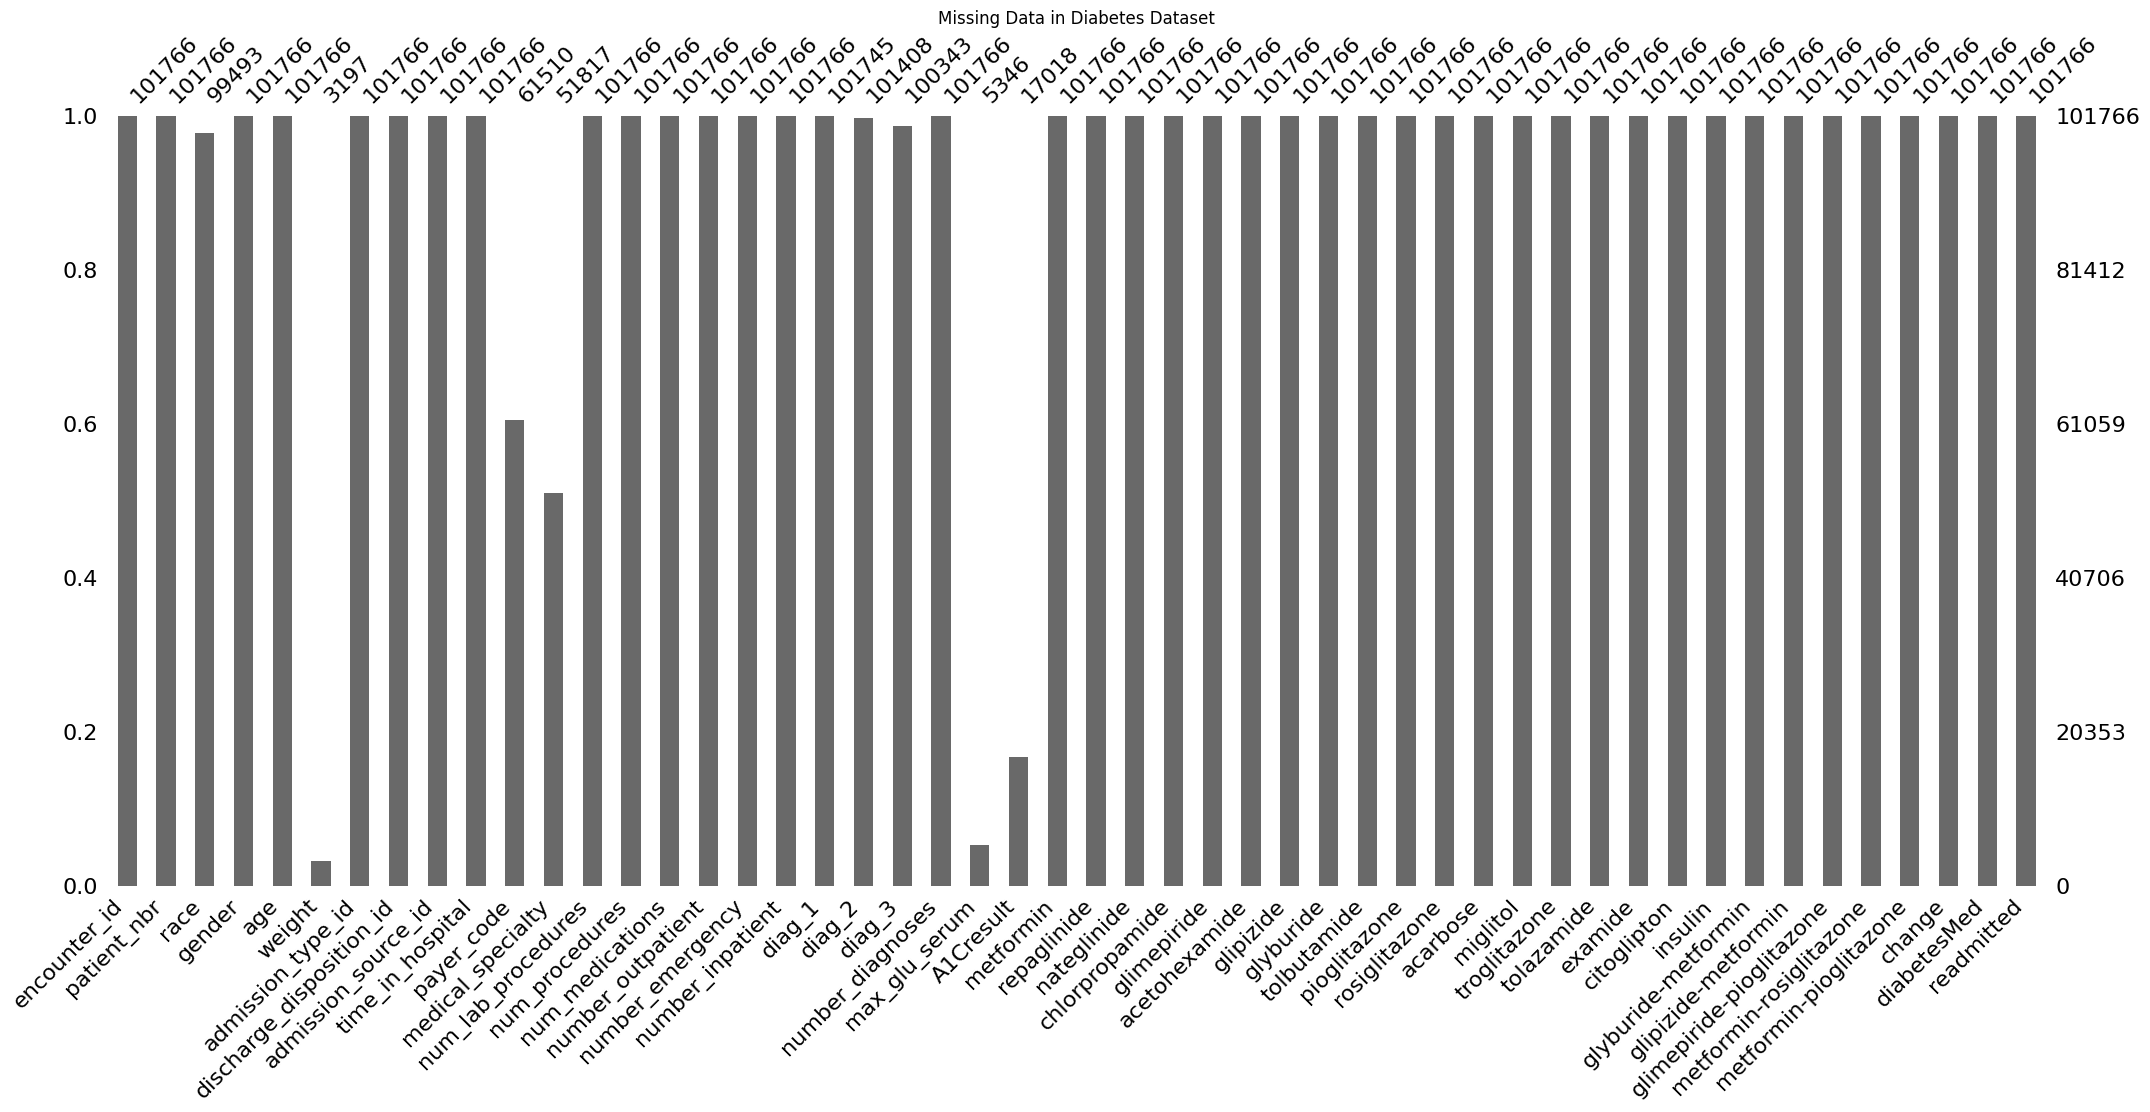

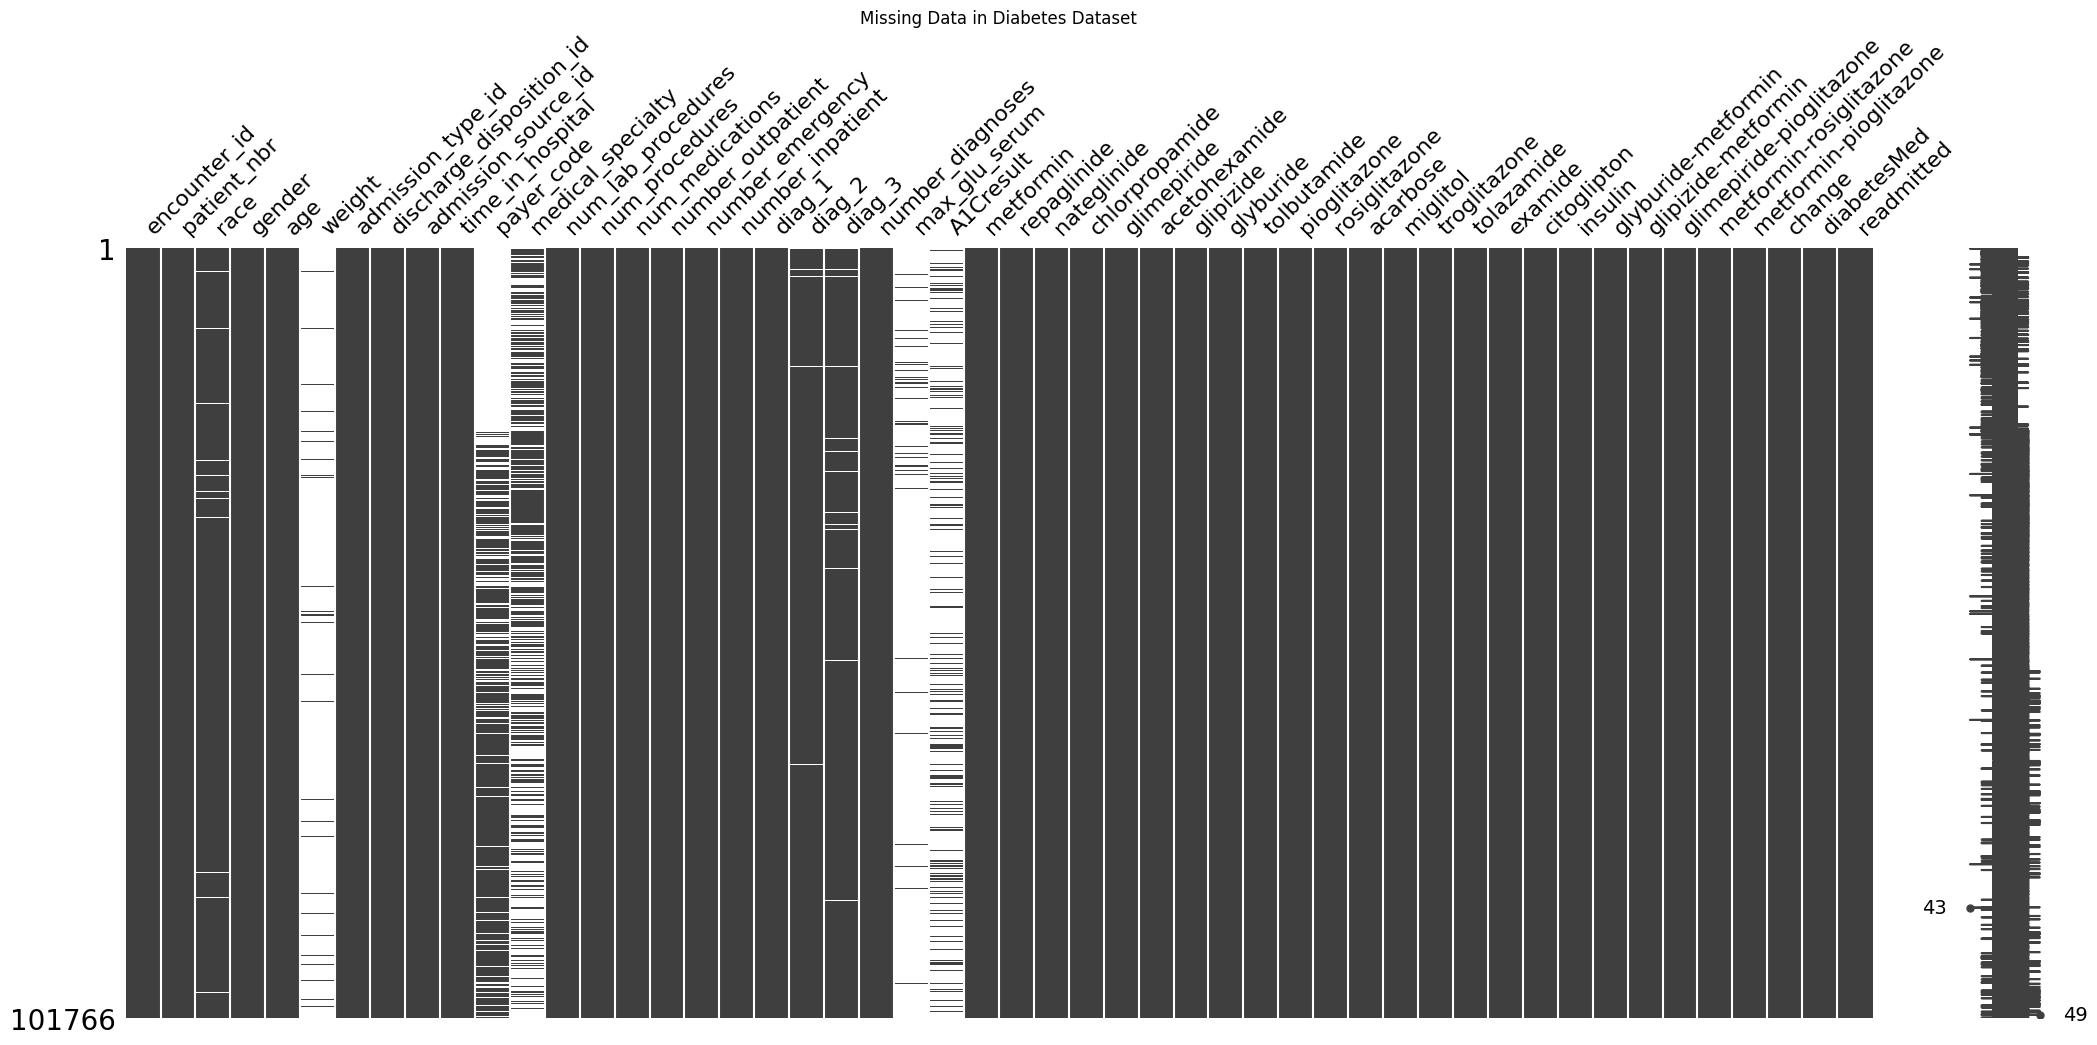

,missing_count,missing_percent
weight,98569,0.968585
max_glu_serum,96420,0.947468
A1Cresult,84748,0.832773
medical_specialty,49949,0.490822
payer_code,40256,0.395574
race,2273,0.022336
diag_3,1423,0.013983
diag_2,358,0.003518
diag_1,21,0.000206
encounter_id,0,0.000000


In [134]:
# The csv files has a lot of "?" which are actually missing values. We will replace them with np.nan for better handling of missing data.
diabetes.replace('?', np.nan, inplace=True)

# missing data bargraph and matrix
msno.bar(diabetes)
plt.title('Missing Data in Diabetes Dataset')
plt.show()
msno.matrix(diabetes)
plt.title('Missing Data in Diabetes Dataset')
plt.show()

# missing data percentage and count
def missing(diabetes):
    missing_count = diabetes.isnull().sum().sort_values(ascending=False)
    missing_percent = (diabetes.isnull().sum() / diabetes.isnull().count()).sort_values(ascending=False)
    missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['missing_count', 'missing_percent'])
    return missing_table

missing(diabetes)


We identified the following with missing data:
|Columns     | Missing Percentage|
|------------------|------------|
|weight            |   96.8585%|
|max_glu_serum	    |   94.7468%|
|A1Cresult         |   83.2773%|
|medical_specialty |	49.0822%|
|payer_code    	|   39.5574%|
|race	    	    |   02.2336%|
|diag_3		    |   01.3983%|
|diag_2		    |   00.3518%|
|diag_1            |   00.0206%|



We decided to remove columns **weight, max_glu_serum, A1Cresults** because of the massive amount of NaN values. Furthermore, we believe that leaving them in to train the ML model would lead to bias.  


For **medical_specialty**, we will keep it because it can be a strong clinical predictor. To fix the missing values, we will put the NaN values as "Unknown" and treat that as its own category.

For **payer_code**, will drop now, and will retest later on as an add-on:
- Baseline model: drop the column because there is roughly 40% missing data. 
- Plan: make 2 models. First model, we drop the payer_code. Second model, we run a version with the missing category plus a missing flag. Then compare the 2 using cross-validation on recall, F1, and AUROC for 30-day readmission. We will keep it if the version does not improve performance in a stable way.

For **race**, we can either:
- baseline model: place the missing values as unknown and make it into a separate category
- plan for testing model: drop the rows since its only 2%

Since **diag1-3** are ICD-9 codes, mode imputation is a bad idea. It would artificially inflate the apparent prevalence of certain codes. Instead, we can replace the missing values "?", with "Unknown". 


We will also remove **encounter_id** and **patient_nbr** because these columns are identifiers and not necessary to train the model.

## Cleaning Data for the Baseline Model (no payer_code)

### Removing unnecessary/heavily missing columns 

We will create our first basic model with no payer_code. We will make an additional model later on to compare a model with/without payer_code. We will be removing **encounter_id, patient_nbr, weight, max_glu_serum, A1Cresult**, **and payer_code**.

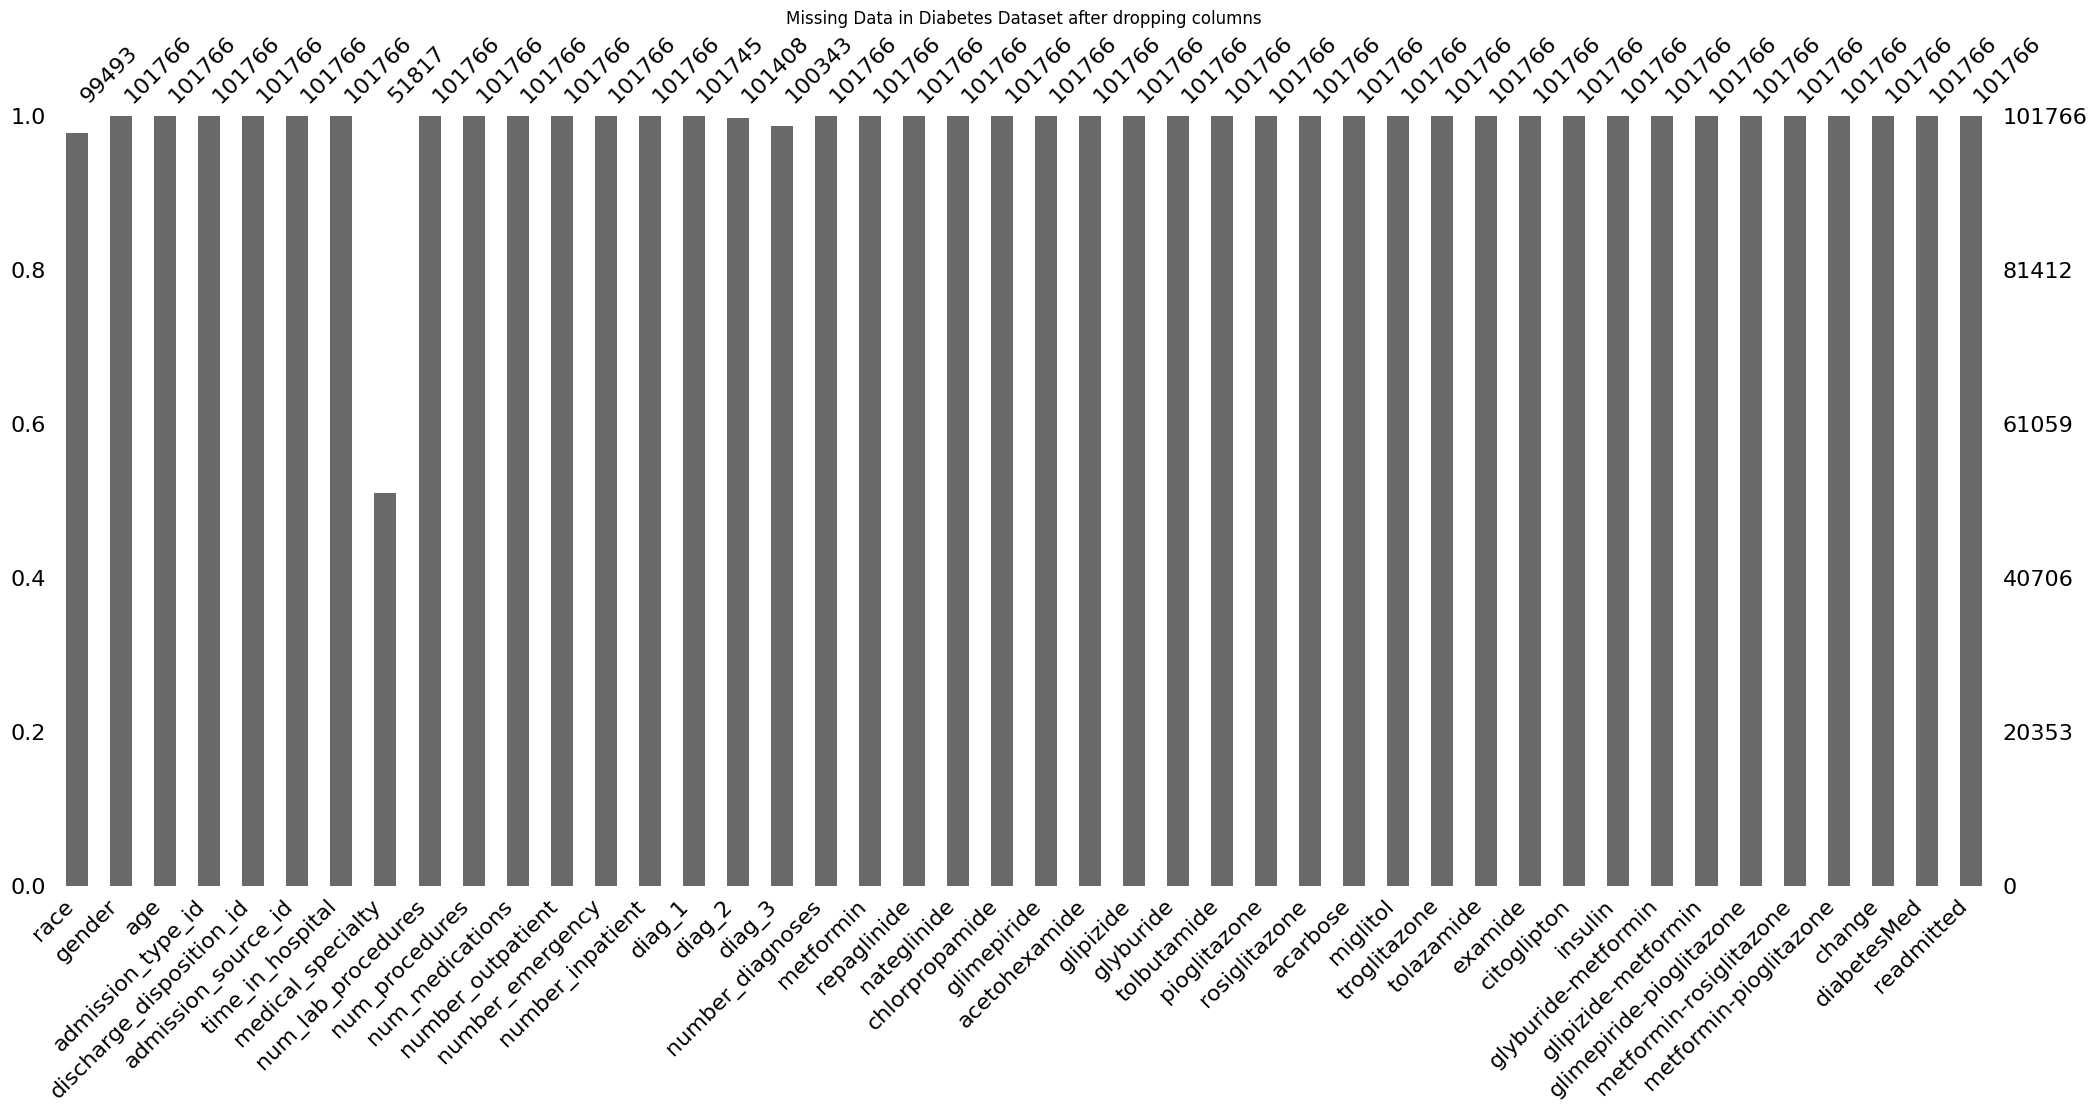

In [135]:
diabetes = diabetes.drop(columns=['weight', 'payer_code', 'encounter_id', 'patient_nbr', 'max_glu_serum', 'A1Cresult'])
diabetes.head()
msno.bar(diabetes)
plt.title('Missing Data in Diabetes Dataset after dropping columns')   
plt.show()


### Adding "Unknown" column to medical_specialty, diag1-3, race
We want to keep all the rows because we believe these rows still provide crucial data. We want to avoid injecting fake labels in the baseline model. 

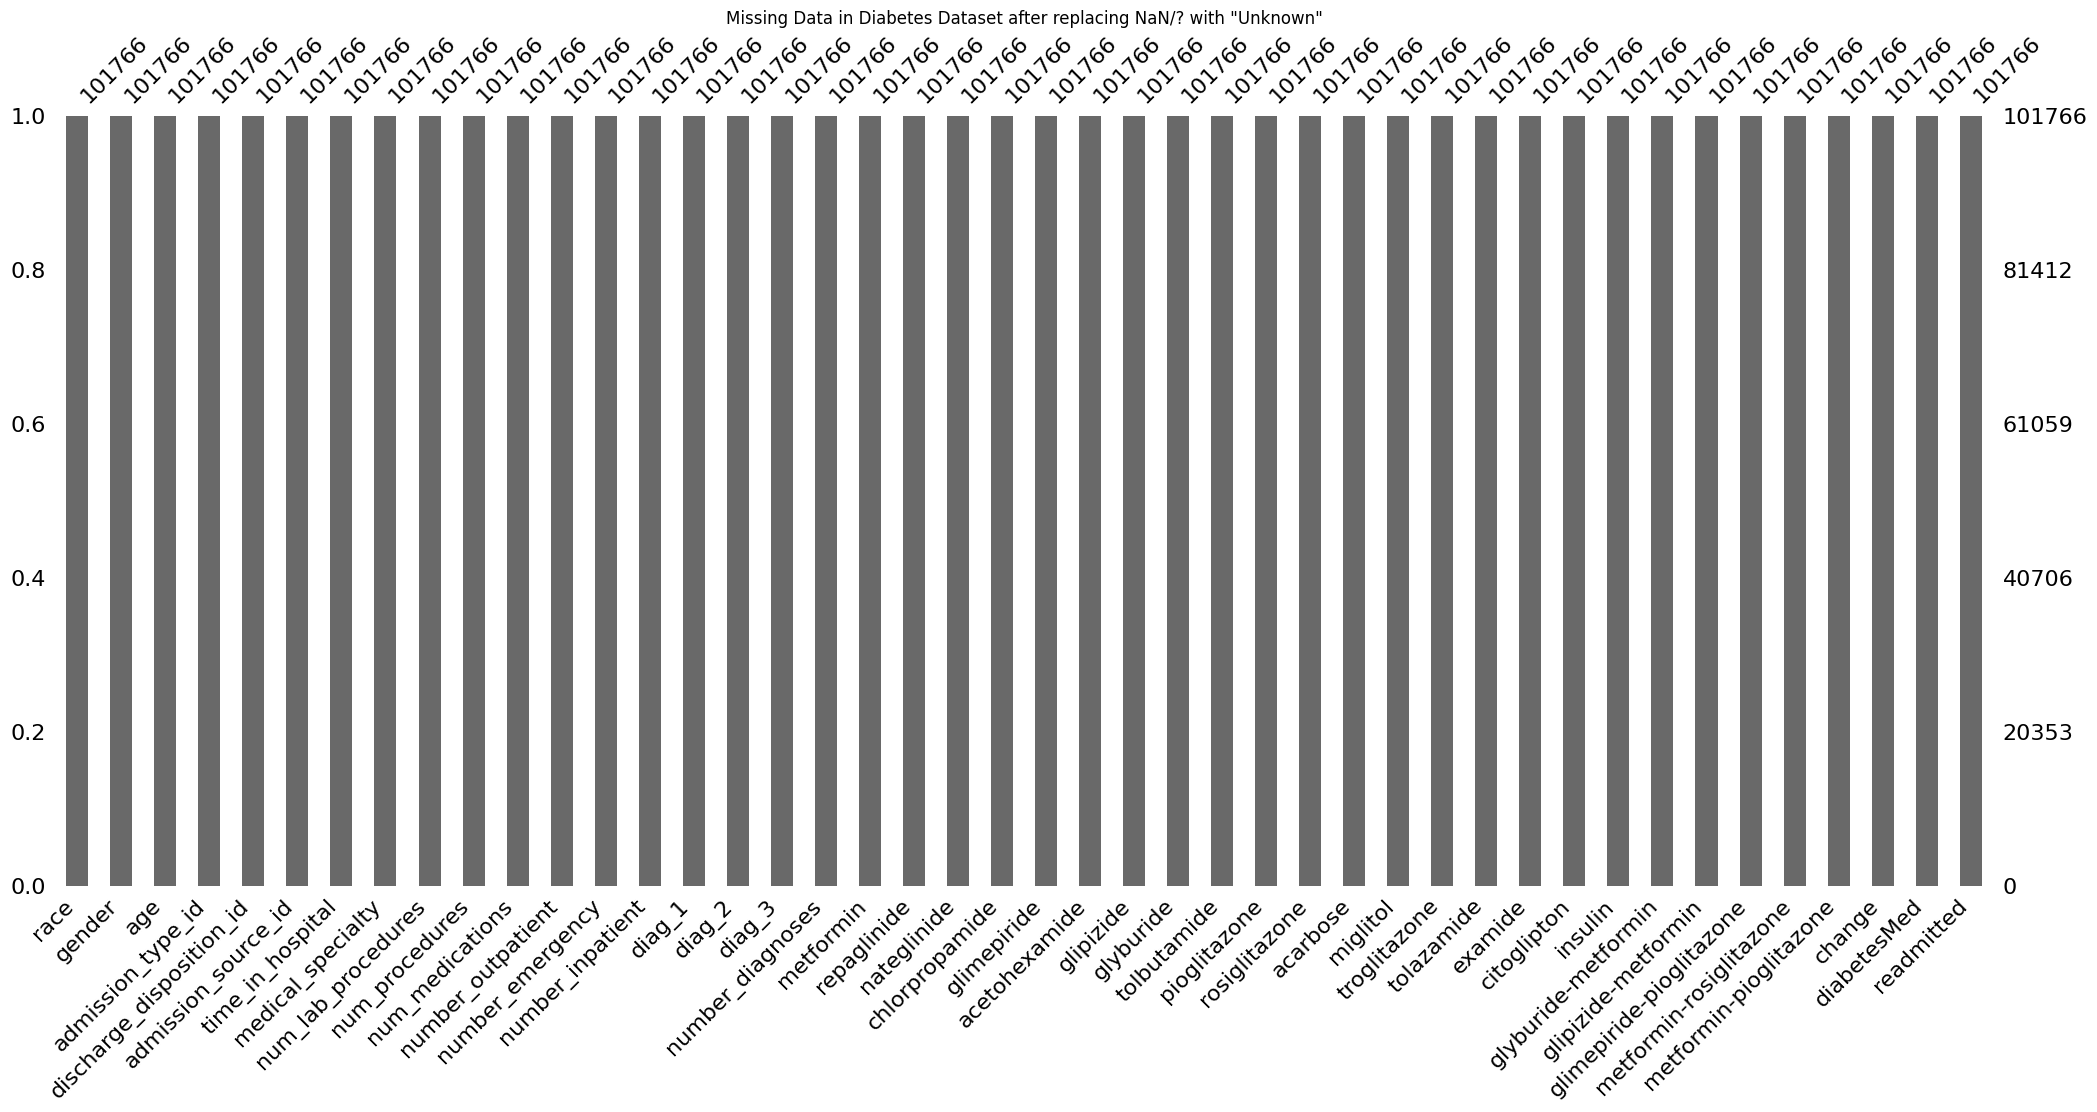

,missing_count,missing_percent
race,0,0.0
gender,0,0.0
glipizide,0,0.0
glyburide,0,0.0
tolbutamide,0,0.0
pioglitazone,0,0.0
rosiglitazone,0,0.0
acarbose,0,0.0
miglitol,0,0.0
troglitazone,0,0.0


In [136]:
# Replace both NaN and '?' with "Unknown" for selected categorical columns
cols_to_replace = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'race']

diabetes[cols_to_replace] = (
    diabetes[cols_to_replace]
    .replace(r'^\s*\?\s*$', np.nan, regex=True)
    .fillna('Unknown')
)

msno.bar(diabetes)
plt.title('Missing Data in Diabetes Dataset after replacing NaN/? with "Unknown"')
plt.show()

# missing data percentage and count
def missing(diabetes):
    missing_count = diabetes.isnull().sum().sort_values(ascending=False)
    missing_percent = (diabetes.isnull().sum() / diabetes.isnull().count()).sort_values(ascending=False)
    missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['missing_count', 'missing_percent'])
    return missing_table

missing(diabetes)

### Converting Categorical Features into Numeric Features
We are going to convert columns like race and gender into numerical columns instead by separating them and have 1 as yes and 0 as no. 

However, there are certain columns that are more difficult, so we will personally convert those into numerical features. They are the age, and group dig1-3.

In [137]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 44 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   admission_type_id         101766 non-null  int64
 4   discharge_disposition_id  101766 non-null  int64
 5   admission_source_id       101766 non-null  int64
 6   time_in_hospital          101766 non-null  int64
 7   medical_specialty         101766 non-null  str  
 8   num_lab_procedures        101766 non-null  int64
 9   num_procedures            101766 non-null  int64
 10  num_medications           101766 non-null  int64
 11  number_outpatient         101766 non-null  int64
 12  number_emergency          101766 non-null  int64
 13  number_inpatient          101766 non-null  int64
 14  diag_1                    10176

#### Grouping diag1-3 into ICD-9 Codes
Diag1-3 have hundreds of unique values so one-hot encoding would explode the features space. To prevent this, we will group these codes into 9 clinical buckets based on ICD-9 code ranges.

In [138]:
# Robust ICD-9 grouping that is safe to re-run
grouped_labels = {
    'Unknown', 'Supplementary', 'External_Causes', 'Infectious_Parasitic',
    'Neoplasms', 'Endocrine_Metabolic', 'Blood_Disorders', 'Mental_Disorders',
    'Nervous_System', 'Circulatory_System', 'Respiratory_System', 'Digestive_System',
    'Genitourinary_System', 'Pregnancy_Childbirth', 'Skin', 'Musculoskeletal_System',
    'Congenital_Anomalies', 'Perinatal', 'Symptoms_Signs', 'Injury_Poisoning', 'Other'
}

def group_icd(code):
    # Handle missing-like values first
    if pd.isna(code):
        return 'Unknown'

    s = str(code).strip()
    if s in grouped_labels:
        return s
    if s in {'?', ''}:
        return 'Unknown'

    s_upper = s.upper()
    if s_upper.startswith('V'):
        return 'Supplementary'
    if s_upper.startswith('E') and len(s_upper) > 1 and s_upper[1].isdigit():
        return 'External_Causes'

    try:
        num = float(s)
        if 1 <= num <= 139:
            return 'Infectious_Parasitic'
        elif 140 <= num <= 239:
            return 'Neoplasms'
        elif 240 <= num <= 279:
            return 'Endocrine_Metabolic'
        elif 280 <= num <= 289:
            return 'Blood_Disorders'
        elif 290 <= num <= 319:
            return 'Mental_Disorders'
        elif 320 <= num <= 389:
            return 'Nervous_System'
        elif 390 <= num <= 459:
            return 'Circulatory_System'
        elif 460 <= num <= 519:
            return 'Respiratory_System'
        elif 520 <= num <= 579:
            return 'Digestive_System'
        elif 580 <= num <= 629:
            return 'Genitourinary_System'
        elif 630 <= num <= 679:
            return 'Pregnancy_Childbirth'
        elif 680 <= num <= 709:
            return 'Skin'
        elif 710 <= num <= 739:
            return 'Musculoskeletal_System'
        elif 740 <= num <= 759:
            return 'Congenital_Anomalies'
        elif 760 <= num <= 779:
            return 'Perinatal'
        elif 780 <= num <= 799:
            return 'Symptoms_Signs'
        elif 800 <= num <= 999:
            return 'Injury_Poisoning'
        else:
            return 'Other'
    except Exception:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    diabetes[col] = diabetes[col].apply(group_icd)

print('diag1-3 grouped categories:')
print(diabetes[['diag_1', 'diag_2', 'diag_3']].head(10))

diag1-3 grouped categories:
                 diag_1               diag_2                diag_3
0   Endocrine_Metabolic              Unknown               Unknown
1   Endocrine_Metabolic  Endocrine_Metabolic   Endocrine_Metabolic
2  Pregnancy_Childbirth  Endocrine_Metabolic         Supplementary
3  Infectious_Parasitic  Endocrine_Metabolic    Circulatory_System
4             Neoplasms            Neoplasms   Endocrine_Metabolic
5    Circulatory_System   Circulatory_System   Endocrine_Metabolic
6    Circulatory_System   Circulatory_System         Supplementary
7    Circulatory_System   Respiratory_System   Endocrine_Metabolic
8    Circulatory_System   Circulatory_System  Infectious_Parasitic
9    Circulatory_System            Neoplasms    Respiratory_System


#### OrdinalEncoder the age column

Because age is in a sequential relationship, we cannot onehotendcoder this feature. 

In [139]:
# ordinalencode for age column
age_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}
diabetes['age'] = diabetes['age'].map(age_mapping)
diabetes.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,0,6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,1,1,1,7,3,Unknown,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,2,1,1,7,2,Unknown,11,5,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,3,1,1,7,2,Unknown,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,4,1,1,7,1,Unknown,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### Clean readmission column so only <30 day remission is 0 while >30 day readmission and no readmission is 0

The project only is asking for <30 day readmission prediction. All other values should become 0 (>30 day readmission and no readmission)

In [140]:
# Keep this transformation rerun-safe and deterministic
readmit_map = {
    '<30': 1,
    '>30': 0,
    'NO': 0,
    1: 1,
    0: 0,
    '1': 1,
    '0': 0,
}

diabetes['readmitted'] = diabetes['readmitted'].map(readmit_map)
diabetes.head(15)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,0,6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,1,1,1,7,3,Unknown,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,2,1,1,7,2,Unknown,11,5,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,3,1,1,7,2,Unknown,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,4,1,1,7,1,Unknown,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,Caucasian,Male,5,2,1,2,3,Unknown,31,6,...,No,Steady,No,No,No,No,No,No,Yes,0
6,Caucasian,Male,6,3,1,2,4,Unknown,70,1,...,No,Steady,No,No,No,No,No,Ch,Yes,0
7,Caucasian,Male,7,1,1,7,5,Unknown,73,0,...,No,No,No,No,No,No,No,No,Yes,0
8,Caucasian,Female,8,2,1,4,13,Unknown,68,2,...,No,Steady,No,No,No,No,No,Ch,Yes,0
9,Caucasian,Female,9,3,3,4,12,InternalMedicine,33,3,...,No,Steady,No,No,No,No,No,Ch,Yes,0


#### OneHotEncoder the nominal columns

In [141]:
# onehotencode for nominal categorical columns

nominal_cols = [
    'race',
    'gender',
    'medical_specialty',
    'diag_1',
    'diag_2',
    'diag_3',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'acetohexamide',
    'glipizide',
    'glyburide',
    'tolbutamide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'troglitazone',
    'tolazamide',
    'examide',
    'citoglipton',
    'insulin',
    'glyburide-metformin',
    'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone',
    'change',
    'diabetesMed'
]

diabetes = pd.get_dummies(diabetes, columns=nominal_cols, drop_first=False)

print('Shape after encoding:', diabetes.shape)
print('\ndtypes:')
print(diabetes.dtypes.value_counts())
diabetes.head()


Shape after encoding: (101766, 275)

dtypes:
bool     265
int64     10
Name: count, dtype: int64


,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,...,glimepiride-pioglitazone_No,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
0,0,1,41,0,1,0,0,0,1,0,...,True,False,True,False,True,False,False,True,True,False
1,1,3,59,0,18,0,0,0,9,0,...,True,False,True,False,True,False,True,False,False,True
2,2,2,11,5,13,2,0,1,6,0,...,True,False,True,False,True,False,False,True,False,True
3,3,2,44,1,16,0,0,0,7,0,...,True,False,True,False,True,False,True,False,False,True
4,4,1,51,0,8,0,0,0,5,0,...,True,False,True,False,True,False,True,False,False,True


#### Split into train/test before scaling

#### Scale the continuous column type through StandardScaler only x_train data

The continuous columns in this data set are: 

[time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient,number_emergency, number_inpatient, number_diagnoses]

We need to scale these numbers to standardize these continuous values.

In [142]:
# standardscaler for continuous features
scaler = StandardScaler()
continuous_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                   'num_medications', 'number_outpatient', 'number_emergency',
                   'number_inpatient', 'number_diagnoses']
diabetes[continuous_cols]= scaler.fit_transform(diabetes[continuous_cols])
diabetes.head()

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,...,glimepiride-pioglitazone_No,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
0,0,-1.137649,-0.106517,-0.785398,-1.848268,-0.291461,-0.21262,-0.503276,-3.321596,0,...,True,False,True,False,True,False,False,True,True,False
1,1,-0.467653,0.808384,-0.785398,0.243390,-0.291461,-0.21262,-0.503276,0.815784,0,...,True,False,True,False,True,False,True,False,False,True
2,2,-0.802651,-1.631351,2.145781,-0.371804,1.286748,-0.21262,0.288579,-0.735733,0,...,True,False,True,False,True,False,False,True,False,True
3,3,-0.802651,0.045967,-0.199162,-0.002688,-0.291461,-0.21262,-0.503276,-0.218561,0,...,True,False,True,False,True,False,True,False,False,True
4,4,-1.137649,0.401761,-0.785398,-0.986997,-0.291461,-0.21262,-0.503276,-1.252906,0,...,True,False,True,False,True,False,True,False,False,True
